In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [2]:
data = pd.read_csv('real_estate_price_prediction_dataset_20000.csv')
data.head()

,property_id,city,property_type,area_sqft,bedrooms,bathrooms,parking,furnishing,main_road,school_distance_km,hospital_distance_km,price
0,100001,Panchkula,Independent House,602,1,1,1,Furnished,No,0.45,1.12,5281624
1,100002,Panchkula,Apartment,3432,5,4,2,Unfurnished,No,2.37,2.31,23610251
2,100003,Mohali,Independent House,1970,3,4,0,Semi-Furnished,No,6.67,6.26,17053129
3,100004,Panchkula,Independent House,687,1,1,1,Semi-Furnished,Yes,3.09,2.25,6820514
4,100005,Chandigarh,Apartment,3100,4,5,1,Furnished,No,6.77,7.80,31536451


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   property_id           20000 non-null  int64  
 1   city                  20000 non-null  object 
 2   property_type         20000 non-null  object 
 3   area_sqft             20000 non-null  int64  
 4   bedrooms              20000 non-null  int64  
 5   bathrooms             20000 non-null  int64  
 6   parking               20000 non-null  int64  
 7   furnishing            20000 non-null  object 
 8   main_road             20000 non-null  object 
 9   school_distance_km    20000 non-null  float64
 10  hospital_distance_km  20000 non-null  float64
 11  price                 20000 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 1.8+ MB


In [4]:
data = pd.get_dummies(data).astype(int)
data.head()

,property_id,area_sqft,bedrooms,bathrooms,parking,school_distance_km,hospital_distance_km,price,city_Chandigarh,city_Mohali,city_Panchkula,property_type_Apartment,property_type_Independent House,property_type_Villa,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,main_road_No,main_road_Yes
0,100001,602,1,1,1,0,1,5281624,0,0,1,0,1,0,1,0,0,1,0
1,100002,3432,5,4,2,2,2,23610251,0,0,1,1,0,0,0,0,1,1,0
2,100003,1970,3,4,0,6,6,17053129,0,1,0,0,1,0,0,1,0,1,0
3,100004,687,1,1,1,3,2,6820514,0,0,1,0,1,0,0,1,0,0,1
4,100005,3100,4,5,1,6,7,31536451,1,0,0,1,0,0,1,0,0,1,0


In [5]:
x = data.drop('price', axis=1)
y = data['price']

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
predictions =model.predict(x_test)
predictions[:5]


array([18698579.79068801, 28664266.46596986, 28837445.73924543,
       33456272.19606135, 12604294.89703454])

In [9]:
x_test.head()

,property_id,area_sqft,bedrooms,bathrooms,parking,school_distance_km,hospital_distance_km,city_Chandigarh,city_Mohali,city_Panchkula,property_type_Apartment,property_type_Independent House,property_type_Villa,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,main_road_No,main_road_Yes
10650,110651,2193,3,3,1,3,3,0,1,0,0,1,0,1,0,0,1,0
2041,102042,3289,4,3,0,3,4,0,1,0,0,0,1,1,0,0,0,1
8668,108669,3416,4,3,0,2,7,0,1,0,0,0,1,0,0,1,0,1
1114,101115,3920,6,5,2,1,4,0,0,1,0,0,1,0,1,0,1,0
13902,113903,1191,1,2,0,0,7,1,0,0,1,0,0,0,1,0,1,0


In [10]:
data.describe()

,property_id,area_sqft,bedrooms,bathrooms,parking,school_distance_km,hospital_distance_km,price,city_Chandigarh,city_Mohali,city_Panchkula,property_type_Apartment,property_type_Independent House,property_type_Villa,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,main_road_No,main_road_Yes
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,110000.500000,2248.781900,3.249250,3.170250,1.502750,3.583150,4.599050,2.007893e+07,0.333850,0.330400,0.335750,0.334950,0.335850,0.329200,0.335150,0.331700,0.333150,0.498100,0.501900
std,5773.647028,1009.090608,1.511634,1.428169,1.116403,2.263303,2.844397,8.885745e+06,0.471599,0.470369,0.472264,0.471985,0.472299,0.469934,0.472055,0.470836,0.471351,0.500009,0.500009
min,100001.000000,500.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.346485e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,105000.750000,1371.750000,2.000000,2.000000,1.000000,2.000000,2.000000,1.266170e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,110000.500000,2253.500000,3.000000,3.000000,2.000000,4.000000,5.000000,1.969587e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,115000.250000,3122.000000,4.000000,5.000000,2.000000,6.000000,7.000000,2.693068e+07,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,120000.000000,4000.000000,6.000000,5.000000,3.000000,8.000000,10.000000,4.305010e+07,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


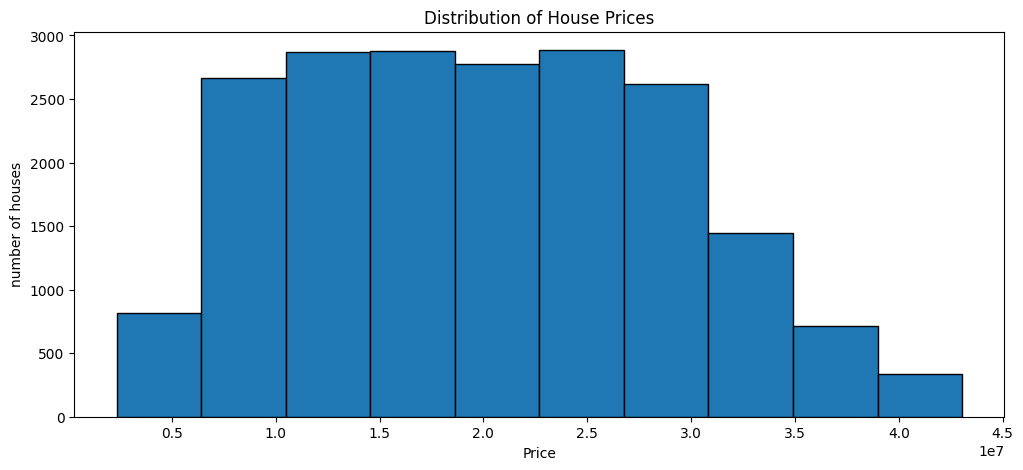

In [11]:
plt.figure(figsize=(12, 5))
plt.hist(data['price'], bins=10, edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('number of houses')
plt.show()

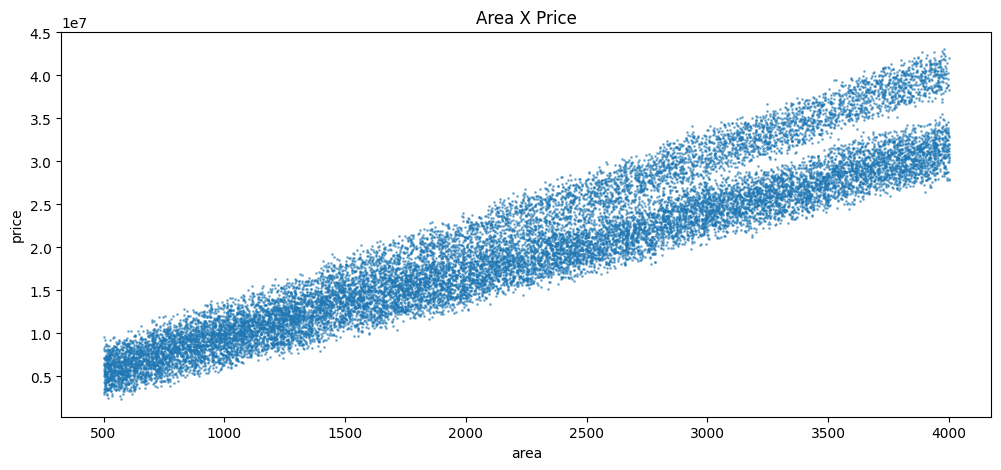

In [12]:
plt.figure(figsize=(12, 5))
plt.scatter(data['area_sqft'],data['price'],s=1 , alpha = 0.5)
plt.title('Area X Price')
plt.xlabel('area')
plt.ylabel('price')
plt.show()

Text(0, 0.5, 'houses')

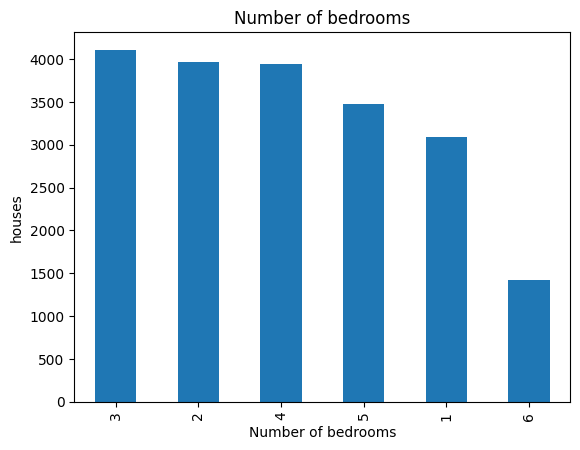

In [13]:
data["bedrooms"].value_counts().plot(kind="bar", title="Number of bedrooms")
plt.xlabel("Number of bedrooms")
plt.ylabel("houses")

In [14]:
from sklearn.metrics import r2_score ,mean_squared_error

In [15]:
mse = mean_squared_error(y_test, predictions)
mse

1536220111749.2505

In [16]:
rscore= r2_score(y_test, predictions)
rscore

0.9806711177807934

In [17]:
y_test.head()

10650    18817660
2041     28015034
8668     27504610
1114     32363374
13902    10896457
Name: price, dtype: int64

In [18]:
x_test.head()

,property_id,area_sqft,bedrooms,bathrooms,parking,school_distance_km,hospital_distance_km,city_Chandigarh,city_Mohali,city_Panchkula,property_type_Apartment,property_type_Independent House,property_type_Villa,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,main_road_No,main_road_Yes
10650,110651,2193,3,3,1,3,3,0,1,0,0,1,0,1,0,0,1,0
2041,102042,3289,4,3,0,3,4,0,1,0,0,0,1,1,0,0,0,1
8668,108669,3416,4,3,0,2,7,0,1,0,0,0,1,0,0,1,0,1
1114,101115,3920,6,5,2,1,4,0,0,1,0,0,1,0,1,0,1,0
13902,113903,1191,1,2,0,0,7,1,0,0,1,0,0,0,1,0,1,0


In [19]:
print("\n========== HOUSE PRICE PREDICTION ==========")
print("\nSelect City")
print("1. Chandigarh")
print("2. Mohali")
print("3. Panchkula")

city = int(input("Enter choice: "))

if city not in [1,2,3]:
    print("Invalid City")
else:
    print("\nProperty Type")
    print("1. Apartment")
    print("2. Independent House")
    print("3. Villa")

    property_type = int(input("Enter choice: "))

    area = float(input("\nEnter Area (500-4000 sqft): "))

    if area < 500 or area > 4000:
        print("Area must be between 500 and 4000 sqft.")

    else:

        bedrooms = int(input("Bedrooms (1-6): "))
        bathrooms = int(input("Bathrooms (1-5): "))
        parking = int(input("Parking Spaces (0-3): "))

        print("\nFurnishing")
        print("1. Furnished")
        print("2. Semi-Furnished")
        print("3. Unfurnished")

        furnishing = int(input("Enter choice: "))

        user_data = pd.DataFrame(0, index=[0], columns=x.columns)

        user_data["area_sqft"] = area
        user_data["bedrooms"] = bedrooms
        user_data["bathrooms"] = bathrooms
        user_data["parking"] = parking

        if city == 1:
            user_data["city_Chandigarh"] = 1

        elif city == 2:
            user_data["city_Mohali"] = 1

        else:
            user_data["city_Panchkula"] = 1

        if property_type == 1:
            user_data["property_type_Apartment"] = 1

        elif property_type == 2:
            user_data["property_type_Independent House"] = 1

        elif property_type == 3:
            user_data["property_type_Villa"] = 1

        if furnishing == 1:
            user_data["furnishing_Furnished"] = 1

        elif furnishing == 2:
            user_data["furnishing_Semi-Furnished"] = 1

        else:
            user_data["furnishing_Unfurnished"] = 1

        predicted_price = model.predict(user_data)

        print("\n===================================")
        print("      HOUSE PRICE PREDICTION")
        print(f"Estimated Price : ₹ {predicted_price[0]/10000000:.2f} Crores")


========== HOUSE PRICE PREDICTION ==========

Select City
1. Chandigarh
2. Mohali
3. Panchkula


Enter choice:  2



Property Type
1. Apartment
2. Independent House
3. Villa


Enter choice:  2

Enter Area (500-4000 sqft):  650
Bedrooms (1-6):  2
Bathrooms (1-5):  1
Parking Spaces (0-3):  2



Furnishing
1. Furnished
2. Semi-Furnished
3. Unfurnished


Enter choice:  1



      HOUSE PRICE PREDICTION
Estimated Price : ₹ 0.64 Crores
